In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [2]:
df = pd.read_csv("06-study_hours_grades.csv")

In [3]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 928.0 bytes


In [5]:
x = torch.tensor(df['study_hours'].values)
y = torch.tensor(df['grade'].values)

In [8]:
x.shape

torch.Size([50])

In [9]:
x.ndim

1

In [10]:
x

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [11]:
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:] 

In [12]:
len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

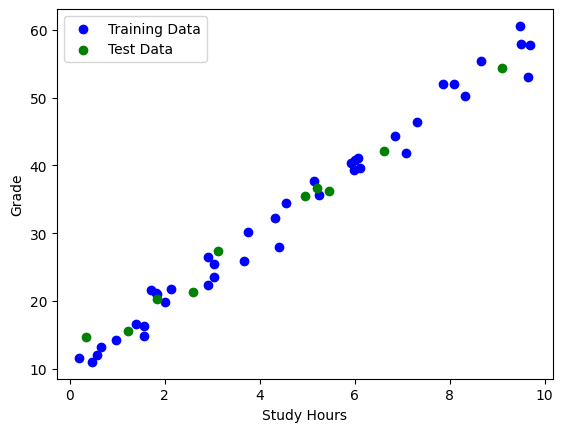

In [13]:
plt.scatter(x_train, y_train, color='blue', label='Training Data')
plt.scatter(x_test, y_test, color='green', label='Test Data')
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.legend()
plt.show()

In [14]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [15]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [16]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [17]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [18]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001)

c:\Users\alica\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
epochs = 200

for epoch in range(epochs):
    model.train()

    y_pred = model(x_train.unsqueeze(1).float())

    loss = loss_fn(y_pred, y_train.unsqueeze(1).float())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(x_test.unsqueeze(1).float())
        test_loss = loss_fn(test_pred, y_test.unsqueeze(1).float())

        if epoch % 5 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Loss: 965.6340 | Test Loss: 717.6833
Epoch: 5 | Loss: 530.0867 | Test Loss: 405.6855
Epoch: 10 | Loss: 295.7362 | Test Loss: 236.0323
Epoch: 15 | Loss: 169.6185 | Test Loss: 143.4254
Epoch: 20 | Loss: 101.7242 | Test Loss: 92.6109
Epoch: 25 | Loss: 65.1511 | Test Loss: 64.5311
Epoch: 30 | Loss: 45.4273 | Test Loss: 48.8660
Epoch: 35 | Loss: 34.7678 | Test Loss: 40.0145
Epoch: 40 | Loss: 28.9846 | Test Loss: 34.9272
Epoch: 45 | Loss: 25.8249 | Test Loss: 31.9371
Epoch: 50 | Loss: 24.0768 | Test Loss: 30.1282
Epoch: 55 | Loss: 23.0883 | Test Loss: 28.9934
Epoch: 60 | Loss: 22.5086 | Test Loss: 28.2496
Epoch: 65 | Loss: 22.1492 | Test Loss: 27.7371
Epoch: 70 | Loss: 21.9086 | Test Loss: 27.3643
Epoch: 75 | Loss: 21.7321 | Test Loss: 27.0778
Epoch: 80 | Loss: 21.5903 | Test Loss: 26.8462
Epoch: 85 | Loss: 21.4676 | Test Loss: 26.6502
Epoch: 90 | Loss: 21.3553 | Test Loss: 26.4779
Epoch: 95 | Loss: 21.2489 | Test Loss: 26.3218
Epoch: 100 | Loss: 21.1459 | Test Loss: 26.1770
Epoch

In [20]:
len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

In [23]:
print(model.state_dict())

OrderedDict([('linear_layer.weight', tensor([[6.1576]])), ('linear_layer.bias', tensor([2.5799]))])


In [24]:
model.eval()
with torch.inference_mode():
    y_pred = model(x_test.unsqueeze(1).float())

In [25]:
y_pred

tensor([[10.0945],
        [33.0710],
        [ 4.6974],
        [58.5723],
        [18.5145],
        [43.3754],
        [21.7738],
        [34.6037],
        [36.2442],
        [13.9625]])

In [26]:
y_test

tensor([15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

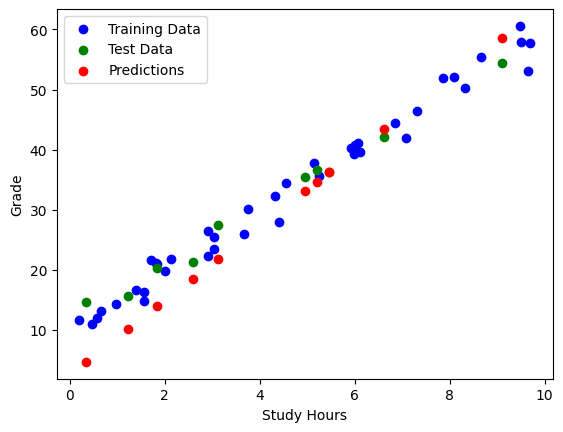

In [27]:
plt.scatter(x_train, y_train, color='blue', label='Training Data')
plt.scatter(x_test, y_test, color='green', label='Test Data')
plt.scatter(x_test, y_pred, color='red', label='Predictions')
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.legend()
plt.show()